In [14]:
import os
import platform

import pandas as pd
import numpy as np
from gensim.models import KeyedVectors
from pingouin import ancova
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from scipy.interpolate import interp1d

In [15]:
import warnings

# RuntimeWarning 무시
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [16]:
os_system = platform.system() # 맥북은 Darwin, 윈도우는 Windows

# 현재 프로젝트 폴더 위치 지정. os.getcwd()는 지금 코드 실행하는 현 위치를 출력해줍니다.
research1_dir = os.getcwd()

# data/processed 폴더 위치 지정
processed_data_dir = research1_dir + ('\\data\\processed\\' if os_system == 'Windows' else '/data/processed/')

# boxplots 이미지 저장할 폴더 위치 지정
graph_image_dir = research1_dir + ('\\graph\\ancova\\' if os_system == 'Windows' else '/graph/ancova/')
# 폴더 없으면 생성
os.makedirs(graph_image_dir, exist_ok=True)

In [17]:
# 테이블 읽어오기
similarity_data = pd.read_csv(processed_data_dir + 'similarity_coherence.csv', encoding='ISO-8859-1')
survey_data = pd.read_csv(processed_data_dir + 'survey_data.csv', encoding='ISO-8859-1')

## 그룹간 cosine similarity의 시행별 추이의 차이
### moving window적용

In [18]:
def calculate_moving_average(data, window_size=8, moving_size=4):
    moving_average_data = pd.DataFrame()
    index=1
    for i in range(0, len(data.columns) - window_size + 1, moving_size):
        window_data = data.iloc[:, i:i + window_size]
        window_mean = window_data.mean(axis=1) 
        moving_average_data[f'{index}'] = window_mean
        index += 1

    return moving_average_data

### ANCOVA

In [19]:
def analyze_ancova_for_each_column(data, column_len: int, between: str, covar: list):
    significant_0_05 = [] # p<0.5
    significant_0_01 = [] # p<0.1
    significant_0_001 = [] # p<0.01
    p_values = []
    
    # 각 열(1에서 27까지)에 대한 ANCOVA 실행
    for column_number in range(1, column_len):
        ancova_result = ancova(data=data, dv=f'{column_number}', between=between, covar=covar)
        p_value = ancova_result['p-unc'][0]
        p_values.append((int(column_number), ancova_result['p-unc'][0]))

        print(f"Column {column_number} ANCOVA Results:")
        print(ancova_result)
        print()

        if p_value < 0.05:
            significant_0_05.append(column_number)
        if p_value < 0.01:
            significant_0_01.append(column_number)
        if p_value < 0.001:
            significant_0_001.append(column_number)

    return p_values, significant_0_05, significant_0_01, significant_0_001

### similairty line graph

In [37]:
def draw_similarity_line_graph(data, target_columns: list, significant_list: list, window_size: int, seed_word: str, filename: str, ax=None):
    low = data.loc[data['group_NA'] == 1].iloc[:, :len(target_columns)]
    high = data.loc[data['group_NA'] == 2].iloc[:, :len(target_columns)]

    low_datas = low.mean()
    high_datas = high.mean()

    plt.figure(figsize=(8, 6))
    plt.plot(high_datas, marker='.', color='#7a58a3', linestyle='-', label='High')
    plt.plot(low_datas, marker='.', color='#73a69e', linestyle='--', label='low')

    # 유의한 점 표시
    for point in significant_list:
        plt.axvspan(point - 1.5, point - 0.5, alpha=0.2, color='gray')
        # *: 여기 point-1.05, y_high_interp[point-1] + "실수"부분으로 조정 가능
        plt.text(point-1.05, high_datas[point-1] + 0.005, '*', fontsize=10, color='#7a58a3')
        
    plt.title(f'Seed word: {seed_word}', fontsize=15, weight='bold')
    plt.ylim(0, 0.2)
    plt.legend(loc='upper right')
    # plt.xticks(range(0, len(low_datas), window_size))

    filepath = filepath = os.path.join(graph_image_dir, filename)
    plt.savefig(filepath, dpi=300)

    # plt.show()


### similairty smoothing graph

In [38]:
def draw_similarity_smoothing_graph(data, target_columns: list, significant_list: list, window_size: int, seed_word:str, filename: str):
    def interpolate_data(values, interpolation_interval=0.1):
        x = np.arange(0, len(values))
        x_interp = np.arange(0, len(values), interpolation_interval)

        interpolation_function = interp1d(x, values, kind='quadratic', fill_value='extrapolate')
        y_interp = interpolation_function(x_interp)
        
        return x_interp, y_interp

    
    low = data.loc[data['group_NA'] == 1].iloc[:, :len(target_columns)]
    high = data.loc[data['group_NA'] == 2].iloc[:, :len(target_columns)]

    low_datas = low.mean()
    high_datas = high.mean()

    # low 및 high 데이터 모두 보간
    x_low_interp, y_low_interp = interpolate_data(low_datas.values, interpolation_interval=0.1)
    x_high_interp, y_high_interp = interpolate_data(high_datas.values, interpolation_interval=0.1)
    # 보간 된 데이터의 표준 오차 계산
    low_sem_interp = y_low_interp.std(axis=0, ddof=1) / np.sqrt(len(x_low_interp)) if y_low_interp.std(axis=0, ddof=1) != 0 else 1.0 / np.sqrt(len(x_low_interp))
    high_sem_interp = y_high_interp.std(axis=0, ddof=1) / np.sqrt(len(x_high_interp)) if y_high_interp.std(axis=0, ddof=1) != 0 else 1.0 / np.sqrt(len(x_high_interp))

    # 원래 데이터에 대한 신뢰 구간 계산
    confidence_interval = 1.96  # 95% 신뢰 구간
    lower_bound_low = y_low_interp - confidence_interval * low_sem_interp
    upper_bound_low = y_low_interp + confidence_interval * low_sem_interp
    lower_bound_high = y_high_interp - confidence_interval * high_sem_interp
    upper_bound_high = y_high_interp + confidence_interval * high_sem_interp


    plt.figure(figsize=(8, 6))

    #  신뢰구간 색칠
    plt.fill_between(x_low_interp, lower_bound_low, upper_bound_low, color='#73a69e', alpha=0.3)
    plt.fill_between(x_high_interp, lower_bound_high, upper_bound_high, color='#7a58a3', alpha=0.3)

    # 스무딩 그래프
    plt.plot(x_high_interp, y_high_interp, color='#7a58a3', linestyle='-', label='High')
    plt.plot(x_low_interp, y_low_interp, color='#73a69e', linestyle='--', label='Low')

    # 유의한 점 표시
    for point in significant_list:
        plt.axvspan(point - 1.5, point - 0.5, alpha=0.2, color='gray')
        # *: 여기 point-1.05, y_high_interp[point-1] + "실수"부분으로 조정 가능
        plt.text(point-1.05, high_datas[point-1] + 0.005, '*', fontsize=10, color='#7a58a3') 

    plt.title(f'Seed word: {seed_word}', fontsize=15, weight='bold')
    plt.ylim(0, 0.2)
    plt.legend(loc='upper right')
    # plt.xticks(range(0, len(low_smoothed_values), window_size))

    filepath = filepath = os.path.join(graph_image_dir, filename)
    plt.savefig(filepath, dpi=300)

    # plt.show()

## multiple comparison

In [39]:
def benjamini_hochberg_correction(p_values, alpha=0.05):
    fdr_significant_0_05 = [] # p<0.5
    fdr_significant_0_01 = [] # p<0.1
    fdr_significant_0_001 = [] # p<0.01

    p_values = [item[1] for item in p_values]
    adjusted_p_values = multipletests(p_values, method='fdr_bh', alpha=alpha)[1]

    for i, p_value in enumerate(adjusted_p_values):
        if p_value < 0.05:
            fdr_significant_0_05.append(i+1)
        if p_value < 0.01:
            fdr_significant_0_01.append(i+1)
        if p_value < 0.001:
            fdr_significant_0_001.append(i+1)

    return adjusted_p_values, fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001

# main code

In [40]:
seed_words = ['tear', 'family', 'mirror', 'abuse']
target_words = ['money', 'friend', 'relationships', 'family'] 

In [41]:
similarity_datas = {
    'tear_money': similarity_data.iloc[:, 1:41],
    'family_money': similarity_data.iloc[:, 41:81],
    'mirror_money': similarity_data.iloc[:, 81:121],
    'abuse_money': similarity_data.iloc[:, 121:161],

    'tear_friend': similarity_data.iloc[:, 161:201],
    'family_friend': similarity_data.iloc[:, 201:241],
    'mirror_friend': similarity_data.iloc[:, 241:281],
    'abuse_friend': similarity_data.iloc[:, 281:321],

    'tear_relationships': similarity_data.iloc[:, 321:361],
    'family_relationships': similarity_data.iloc[:, 361:401],
    'mirror_relationships': similarity_data.iloc[:, 401:441],
    'abuse_relationships': similarity_data.iloc[:, 441:481],

    'tear_family': similarity_data.iloc[:, 481:521],
    'family_family': similarity_data.iloc[:, 521:561],
    'mirror_family': similarity_data.iloc[:, 561:601],
    'abuse_family': similarity_data.iloc[:, 601:641]
}

Seed word: tear, Target: money
Column 1 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.001178    1  0.713120  0.399033  0.002196
1       age  0.000064    1  0.038908  0.843755  0.000120
2       sex  0.005769    1  3.492837  0.062537  0.010665
3  Residual  0.535111  324       NaN       NaN       NaN

Column 2 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.000863    1  0.275349  0.600126  0.000852
1       age  0.004042    1  1.289605  0.256963  0.003977
2       sex  0.000039    1  0.012422  0.911327  0.000038
3  Residual  1.012432  323       NaN       NaN       NaN

Column 3 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.000137    1  0.038449  0.844668  0.000119
1       age  0.000448    1  0.125571  0.723300  0.000389
2       sex  0.000002    1  0.000574  0.980901  0.000002
3  Residual  1.152682  323       NaN       NaN       NaN

Column 4 ANCOVA Results:
     Source

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_44415/3757439652.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.05, high_datas[point-1] + 0.005, '*', fontsize=10, color='#7a58a3')
/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_44415/1242911831.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.05, high_datas[point-1] + 0.005, '*', fontsize=10, color='#7a58a3')


보정 전 p-values: [0.5444042811472618, 0.3583994735325531, 0.5603389167365491, 0.5689624639713606, 0.1725012424815197, 0.19683777732123656, 0.3728377708166525, 0.014059683611687064, 0.001256459704933473, 0.007779178045894101, 0.09106934836569401]
보정 후 p-values: [0.56896246 0.51265193 0.56896246 0.56896246 0.36086926 0.36086926
 0.51265193 0.05155217 0.01382106 0.04278548 0.25044071]


Seed word: tear, Target: family
Column 1 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.000127    1  0.032667  0.856684  0.000101
1       age  0.000349    1  0.089571  0.764915  0.000276
2       sex  0.004740    1  1.217381  0.270694  0.003743
3  Residual  1.261561  324       NaN       NaN       NaN

Column 2 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.004136    1  0.848233  0.357740  0.002619
1       age  0.008933    1  1.832082  0.176828  0.005640
2       sex  0.012226    1  2.507560  0.114280  0.007704
3  Residual  1.5748

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_44415/3757439652.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.05, high_datas[point-1] + 0.005, '*', fontsize=10, color='#7a58a3')
/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_44415/1242911831.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.05, high_datas[point-1] + 0.005, '*', fontsize=10, color='#7a58a3')


보정 전 p-values: [0.1720795183734657, 0.11307303062446213, 0.11780931680404663, 0.4581645261681748, 0.2633863447897287, 0.021103044108028424, 0.013607696854468459, 0.16422708302442748, 0.35614095541964286, 0.2515873134809545, 0.3830662151454294]
보정 후 p-values: [0.31547912 0.31547912 0.31547912 0.45816453 0.36215622 0.11606674
 0.11606674 0.31547912 0.42137284 0.36215622 0.42137284]


Seed word: family, Target: friend
Column 1 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.000729    1  0.055155  0.814472  0.000170
1       age  0.005484    1  0.414877  0.519960  0.001279
2       sex  0.004096    1  0.309862  0.578149  0.000955
3  Residual  4.283109  324       NaN       NaN       NaN

Column 2 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.002633    1  0.357428  0.550356  0.001102
1       age  0.000040    1  0.005451  0.941189  0.000017
2       sex  0.036263    1  4.921879  0.027211  0.014964
3  Residual  2.38

...

보정 전 p-values: [0.23732426328462428, 0.12979668345981277, 0.05698385723663133, 0.49647102703753687, 0.979733648850421, 0.27557209814799144, 0.06828573924003709, 0.09820940469666835, 0.039624279310694094, 0.4845548226805213, 0.29690856378609665]
보정 후 p-values: [0.40824928 0.2855527  0.25038104 0.54611813 0.97973365 0.40824928
 0.25038104 0.27007586 0.25038104 0.54611813 0.40824928]


Seed word: mirror, Target: family
Column 1 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.000885    1  0.327094  0.567773  0.001012
1       age  0.002935    1  1.084900  0.298383  0.003348
2       sex  0.001390    1  0.513780  0.474025  0.001588
3  Residual  0.873809  323       NaN       NaN       NaN

Column 2 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.005187    1  1.463257  0.227294  0.004496
1       age  0.001911    1  0.539157  0.463314  0.001661
2       sex  0.000950    1  0.268047  0.604998  0.000827
3  Residual  1.1

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_44415/3757439652.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.05, high_datas[point-1] + 0.005, '*', fontsize=10, color='#7a58a3')
/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_44415/1242911831.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.05, high_datas[point-1] + 0.005, '*', fontsize=10, color='#7a58a3')


보정 전 p-values: [0.8453338775091837, 0.8697103790060102, 0.7298182377357989, 0.02640774173393478, 4.2795706995900164e-05, 0.03006832450748533, 0.016067019242088566, 0.05378319094641917, 0.3297851005652971, 0.5238126137756179, 0.6512601747654836]
보정 후 p-values: [8.69710379e-01 8.69710379e-01 8.69710379e-01 8.26878924e-02
 4.70752777e-04 8.26878924e-02 8.26878924e-02 1.18323020e-01
 6.04606018e-01 8.23134107e-01 8.69710379e-01]


Seed word: abuse, Target: friend
Column 1 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.004925    1  1.153672  0.283581  0.003548
1       age  0.000212    1  0.049669  0.823780  0.000153
2       sex  0.003338    1  0.782055  0.377169  0.002408
3  Residual  1.383040  324       NaN       NaN       NaN

Column 2 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.004350    1  1.014392  0.314605  0.003121
1       age  0.000488    1  0.113846  0.736026  0.000351
2       sex  0.002909    1  0

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_44415/3757439652.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.05, high_datas[point-1] + 0.005, '*', fontsize=10, color='#7a58a3')
/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_44415/1242911831.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.05, high_datas[point-1] + 0.005, '*', fontsize=10, color='#7a58a3')


보정 전 p-values: [0.411424614397646, 0.889558187358922, 0.38814196849263105, 0.5214906397915366, 0.5805777945477889, 0.012293380146569298, 0.044349346666845646, 0.7136126526563593, 0.8446020305737252, 0.8512622227696547, 0.03281289951833929]
보정 후 p-values: [0.88955819 0.88955819 0.88955819 0.88955819 0.88955819 0.13522718
 0.16261427 0.88955819 0.88955819 0.88955819 0.16261427]


Seed word: abuse, Target: family
Column 1 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.002645    1  0.476221  0.490633  0.001468
1       age  0.004173    1  0.751194  0.386740  0.002313
2       sex  0.003256    1  0.586235  0.444436  0.001806
3  Residual  1.799728  324       NaN       NaN       NaN

Column 2 ANCOVA Results:
     Source        SS   DF         F     p-unc       np2
0  group_NA  0.000770    1  0.184511  0.667810  0.000569
1       age  0.000792    1  0.189843  0.663338  0.000586
2       sex  0.000071    1  0.016922  0.896580  0.000052
3  Residual  1.352060 

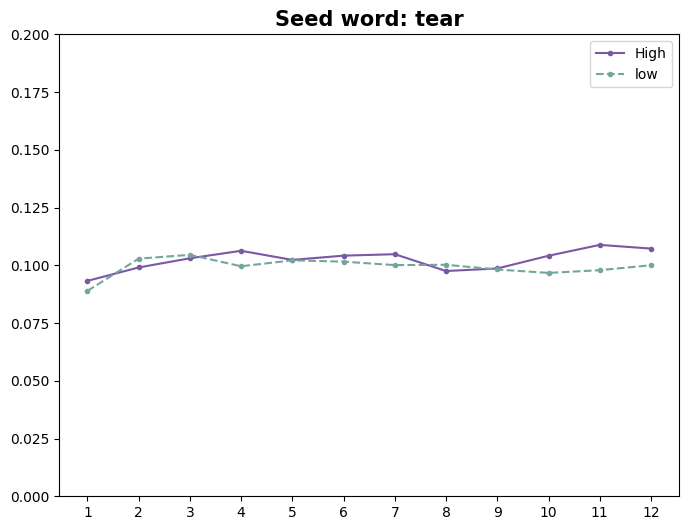

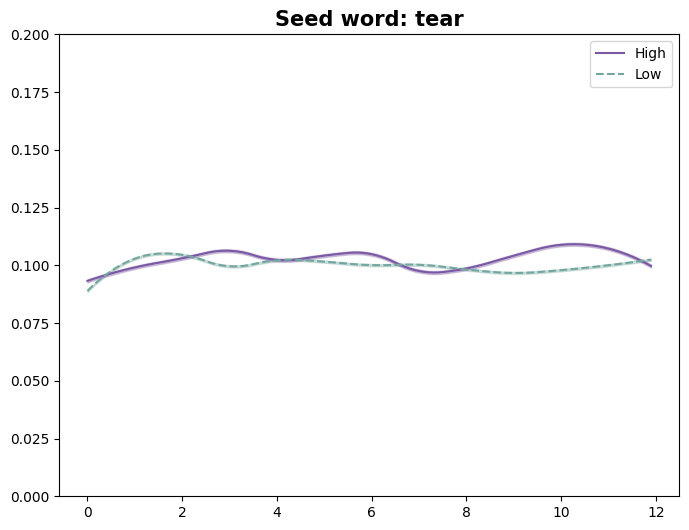

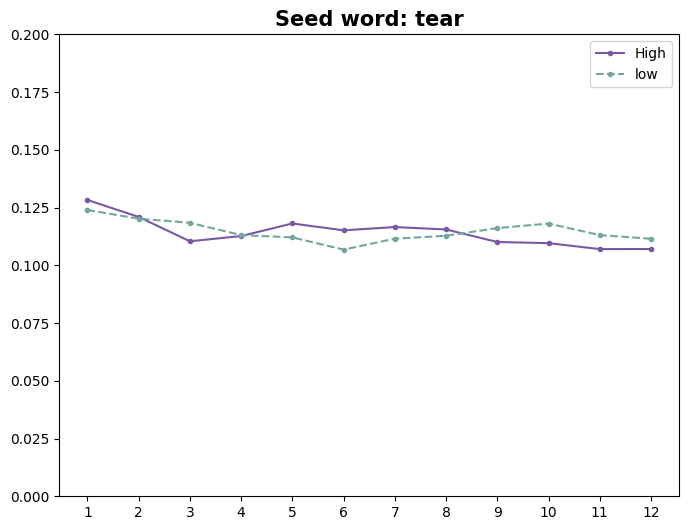

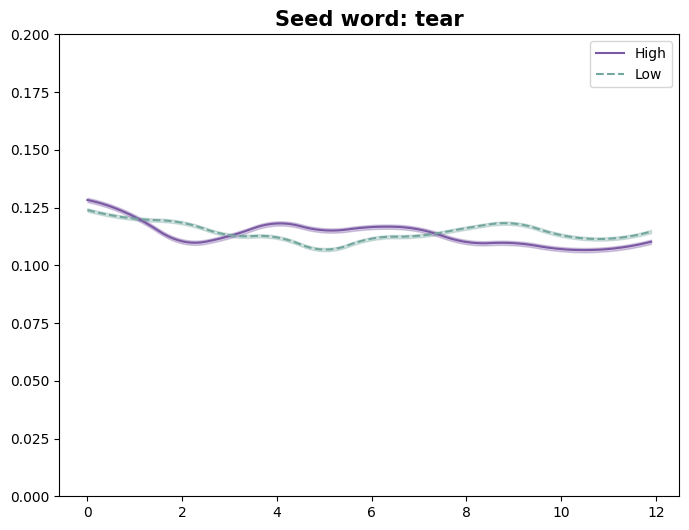

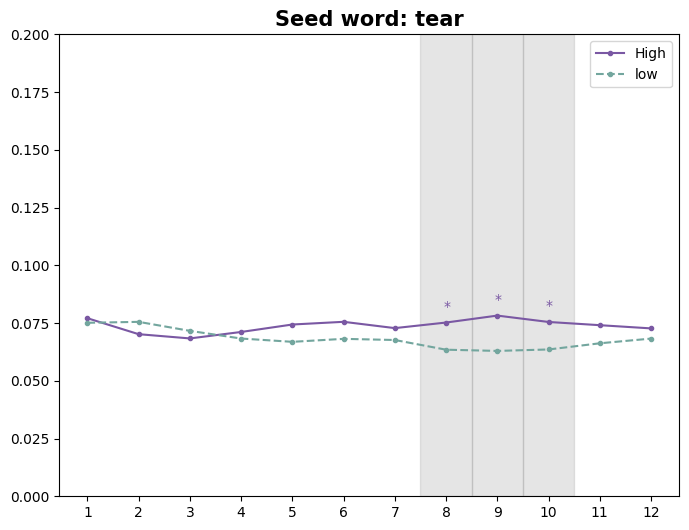

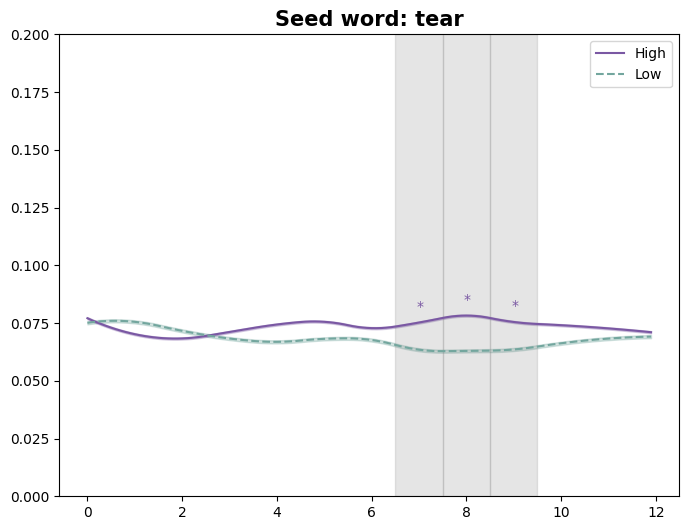

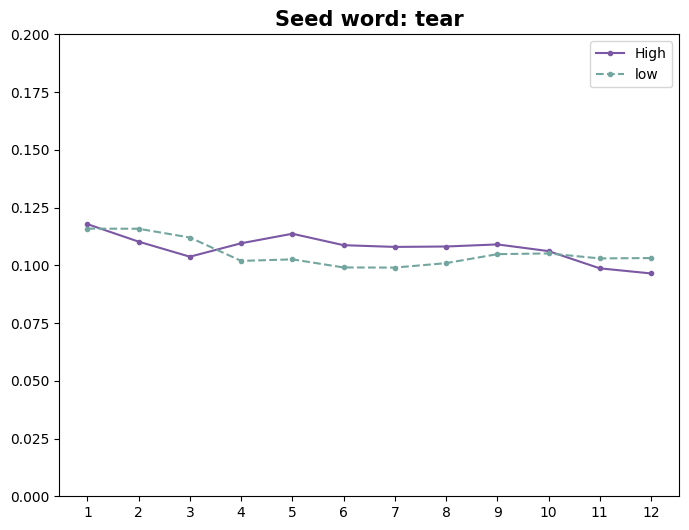

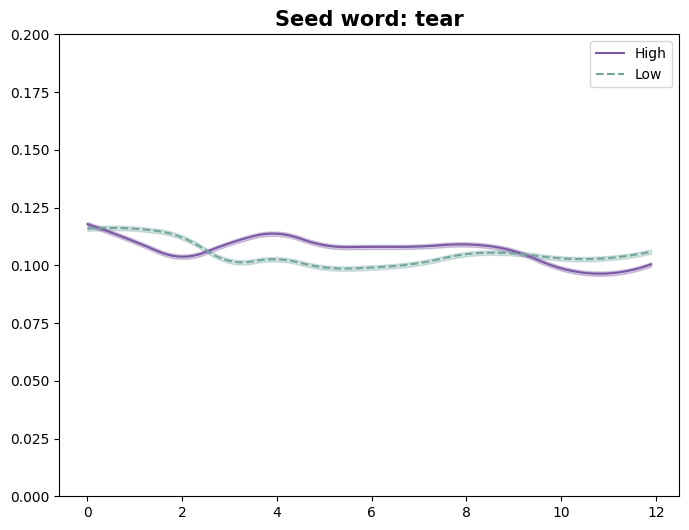

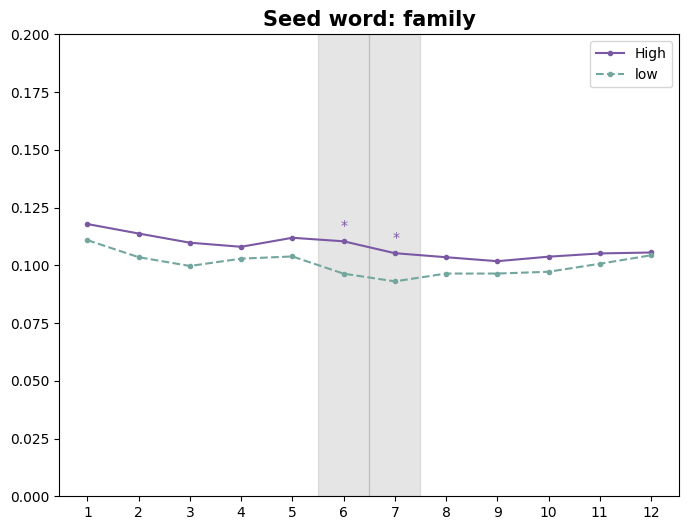

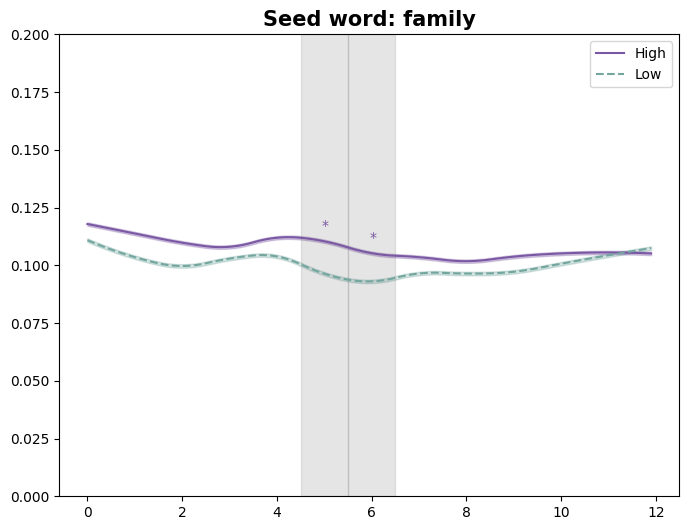

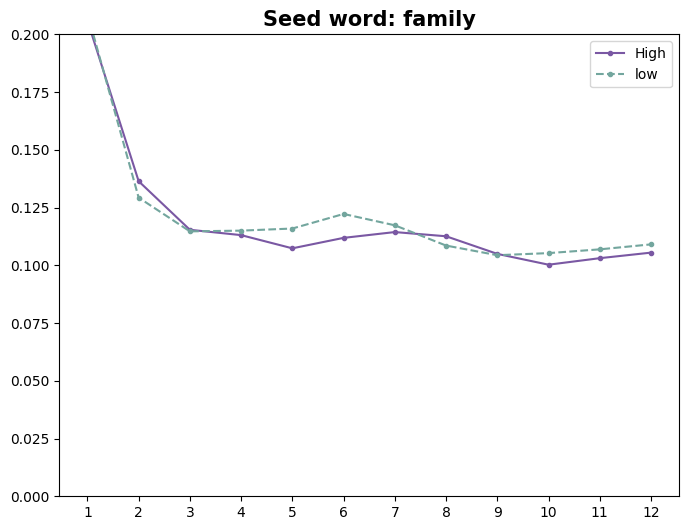

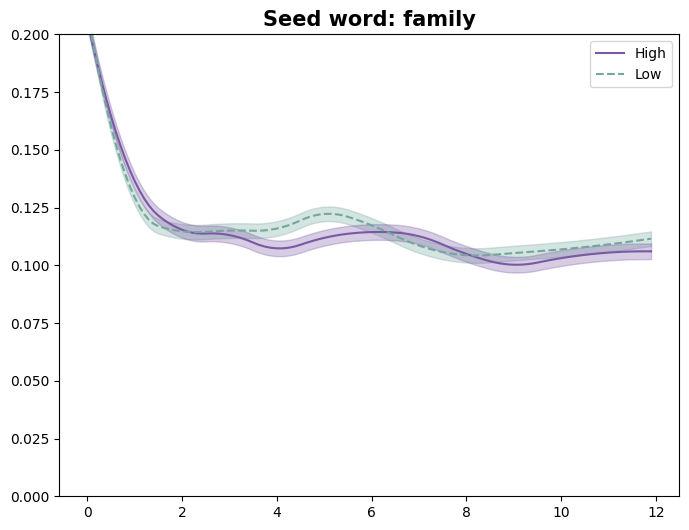

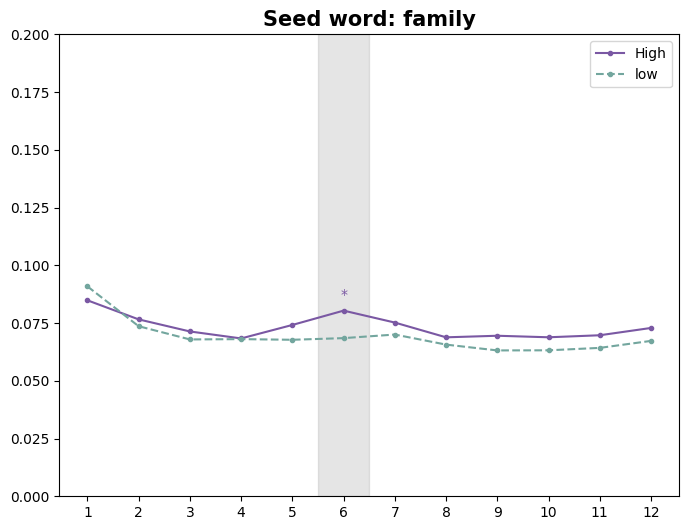

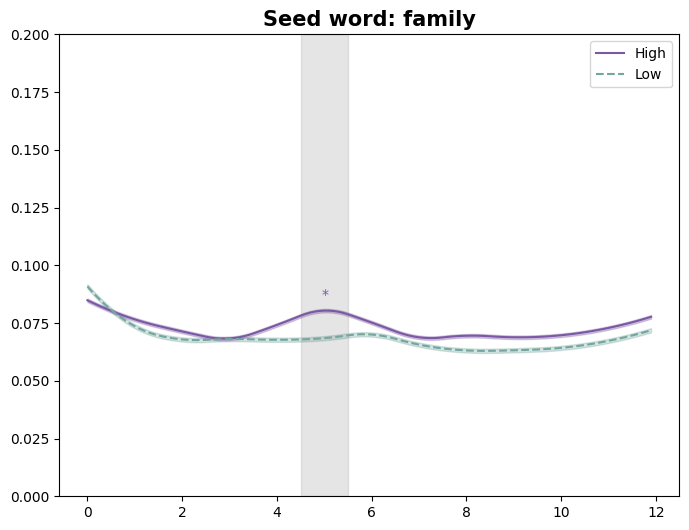

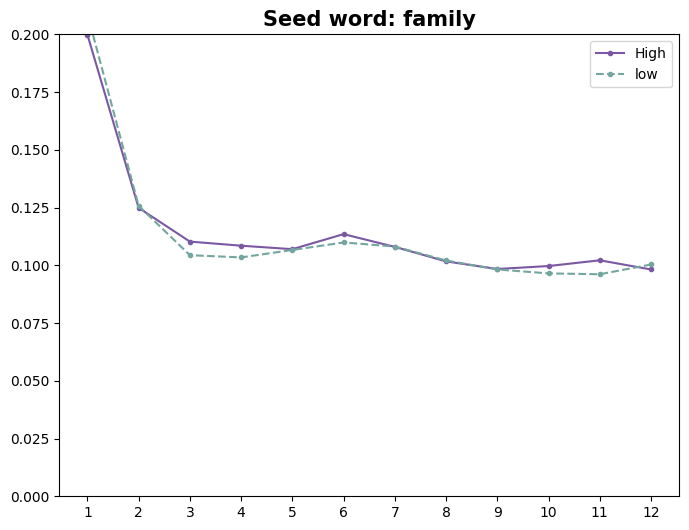

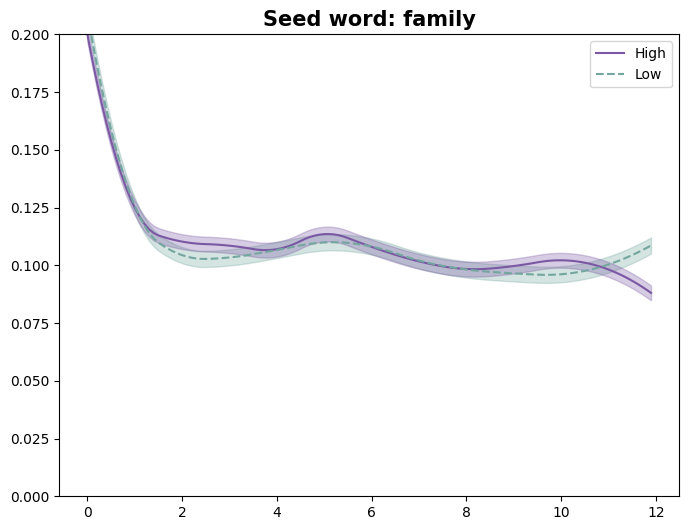

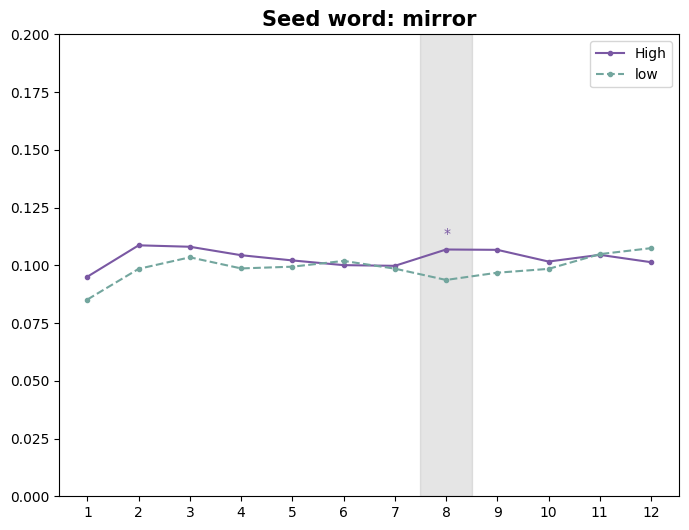

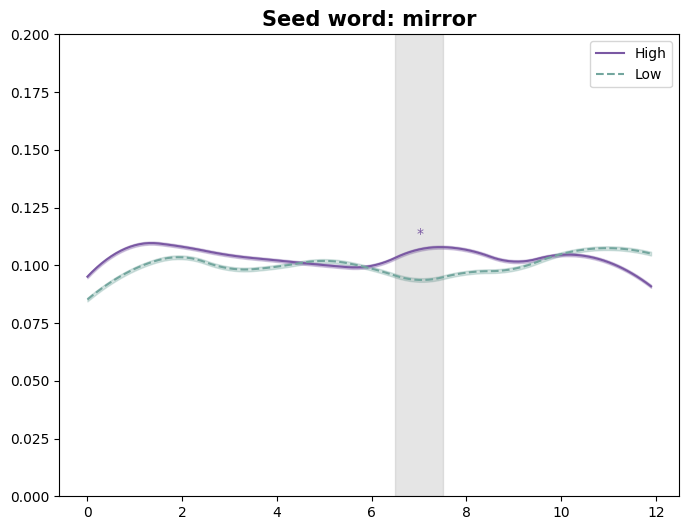

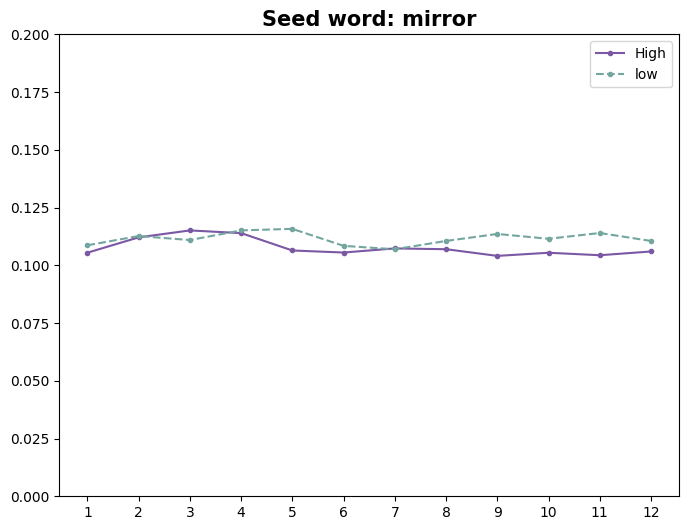

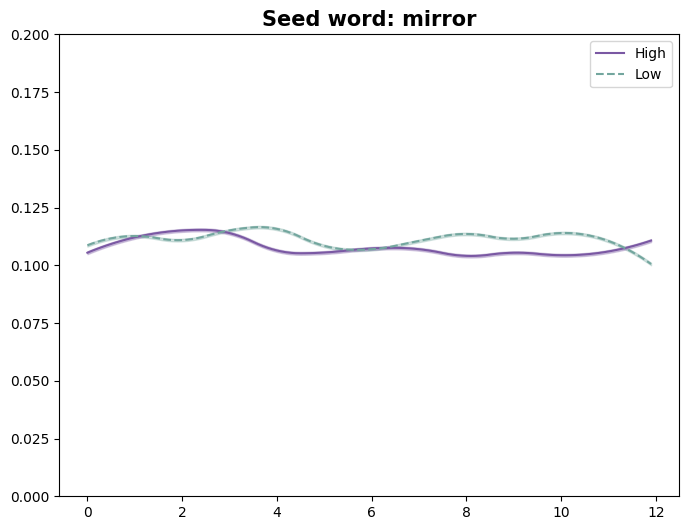

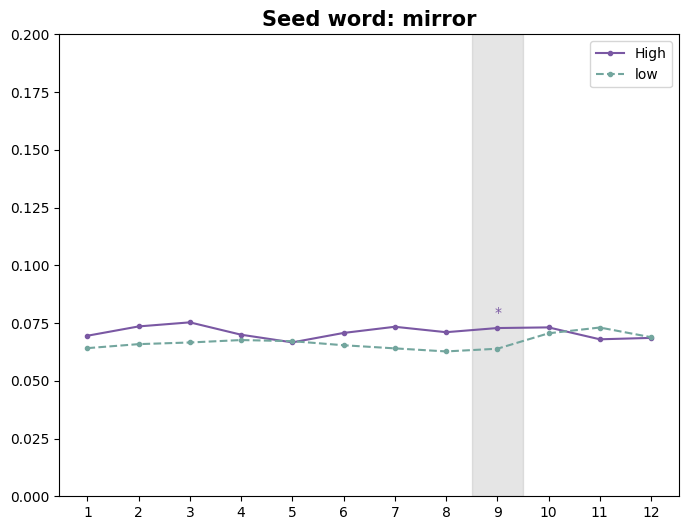

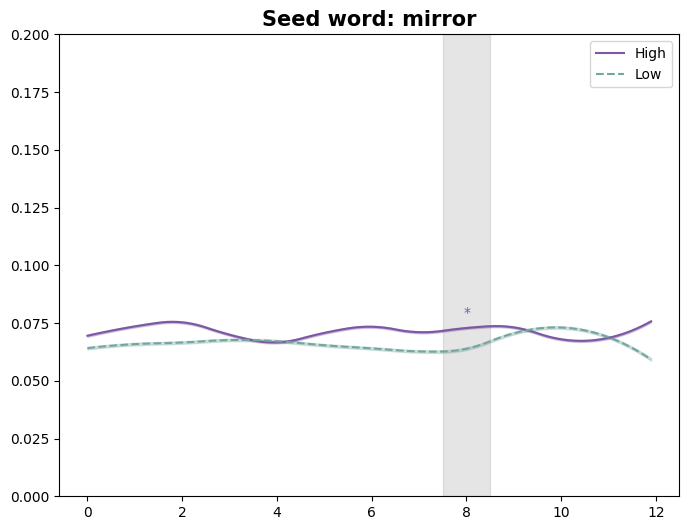

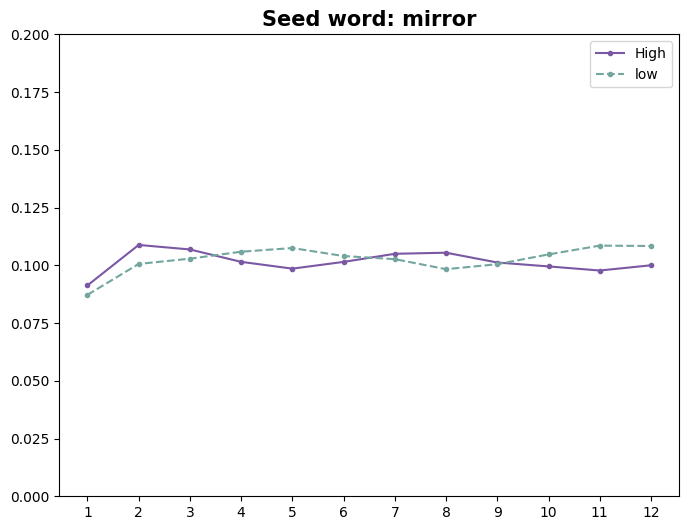

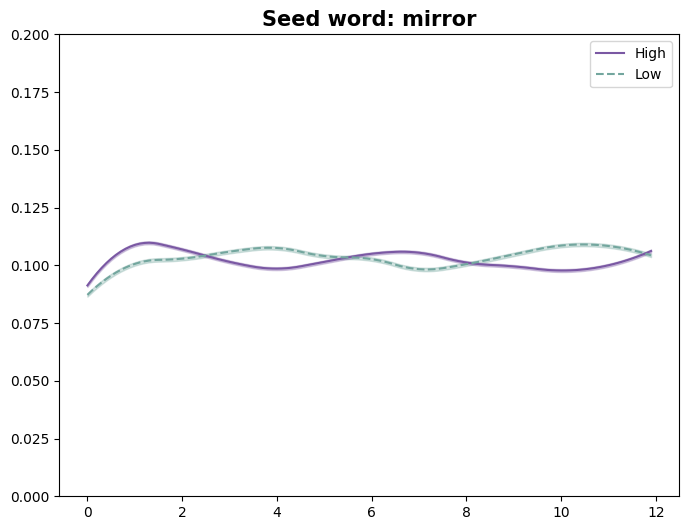

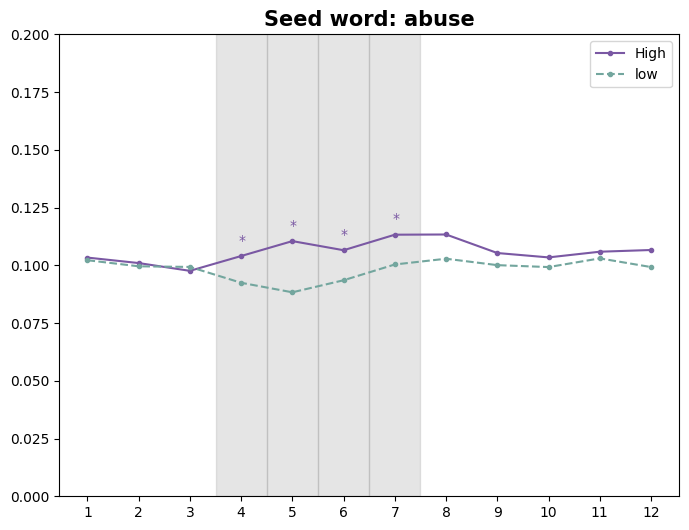

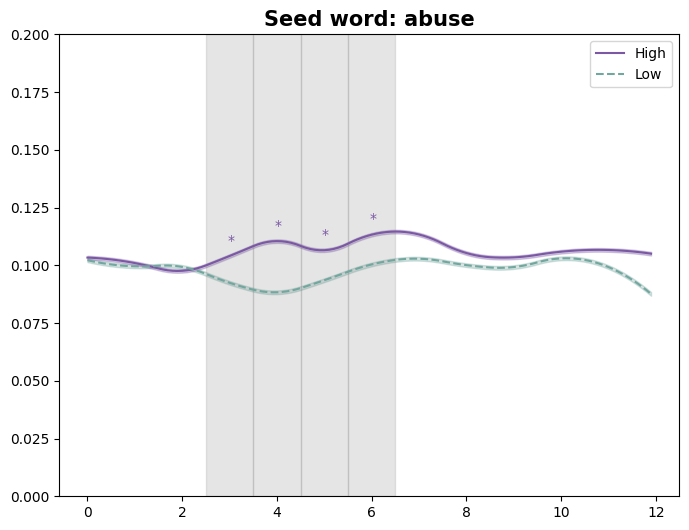

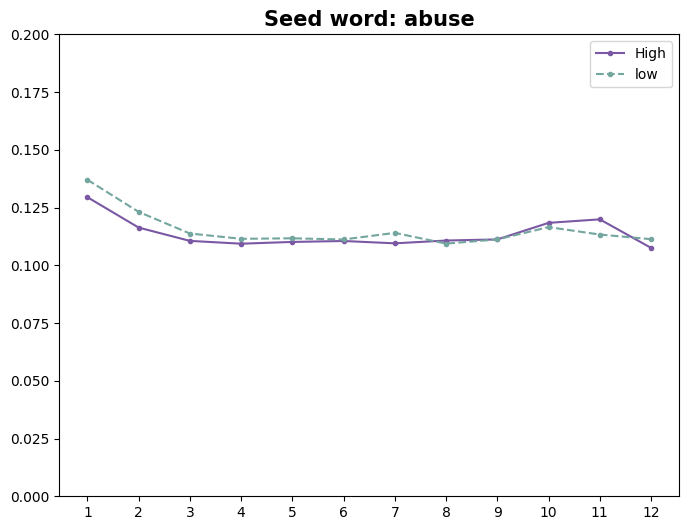

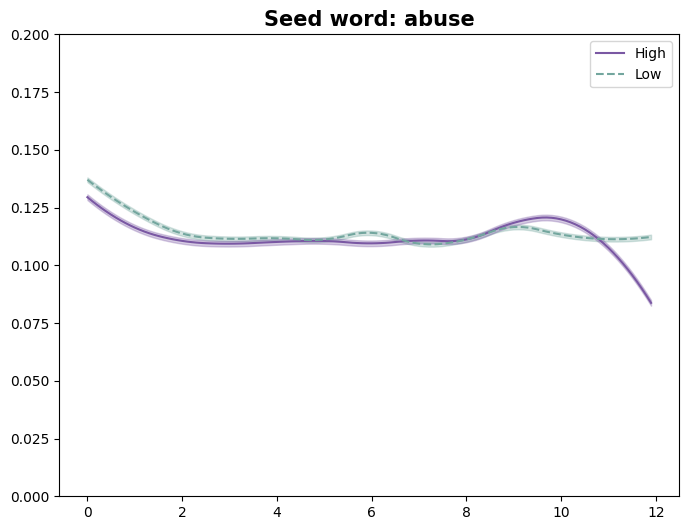

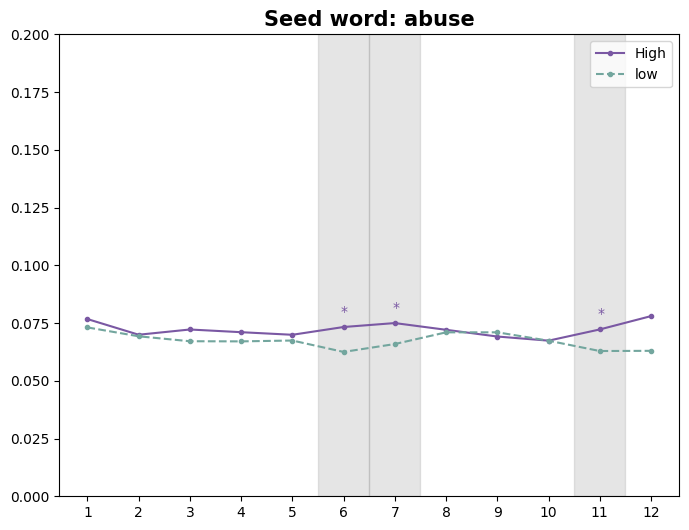

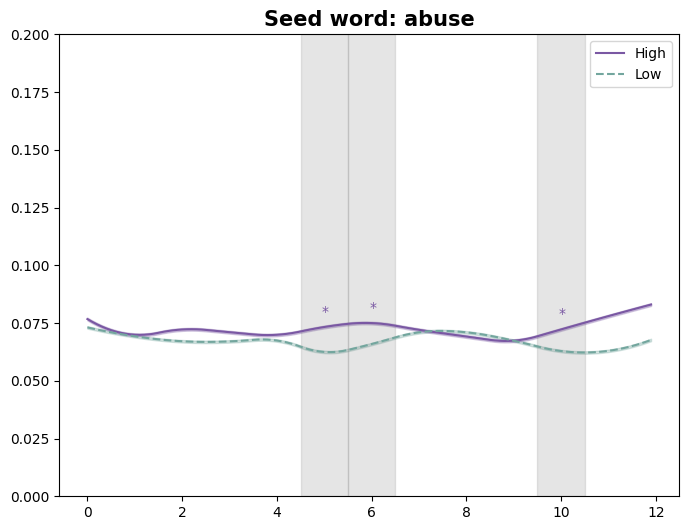

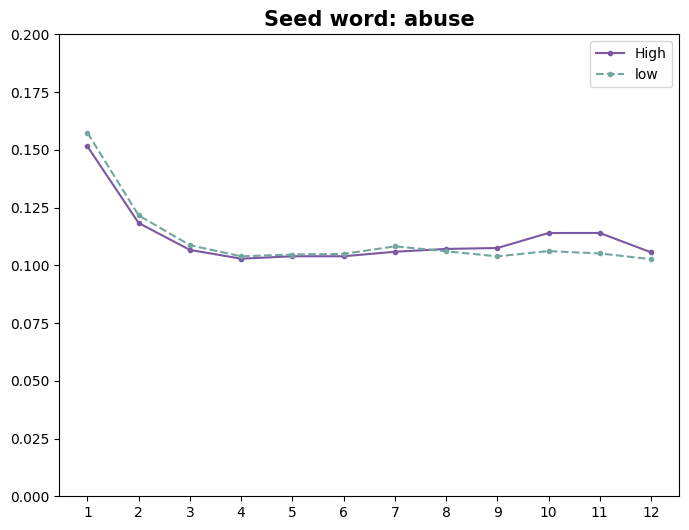

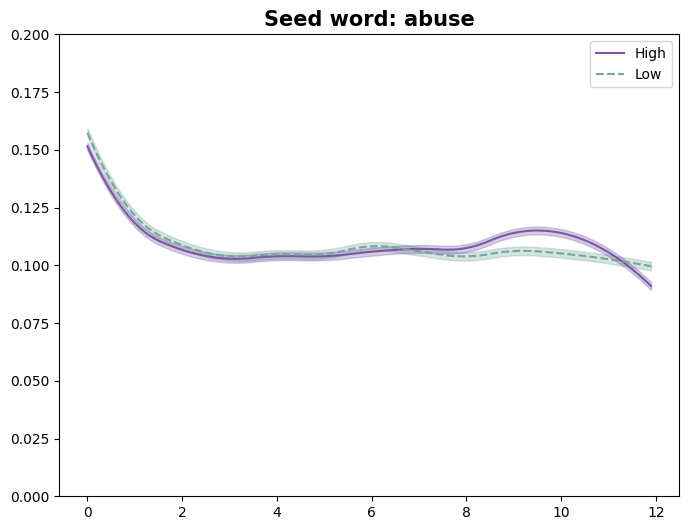

In [44]:
window_size=6
moving_size=3

for i, seed in enumerate(seed_words): # 0~3
    for j, target in enumerate(target_words): # 0~3
        print(f'Seed word: {seed}, Target: {target}')
        data = similarity_datas[f'{seed}_{target}']

        moving_average_df = calculate_moving_average(data=data,
                                                    window_size=window_size,
                                                    moving_size=moving_size)
        # ancova 분석을 위해 데이터 연결
        merged_df = pd.concat([moving_average_df, survey_data], axis=1)

        target_columns = moving_average_df.columns
        # ancova 분석 -> 결과: p값들, significant한 index정보
        p_values, significant_0_05, significant_0_01, significant_0_001 = analyze_ancova_for_each_column(data=merged_df,
                                                                        column_len=len(target_columns),
                                                                        between='group_NA',
                                                                        covar=['age', 'sex'])

        # line graph, smoothing graph 그리기
        draw_similarity_line_graph(data=merged_df,
                                    target_columns=target_columns,
                                    significant_list=significant_0_05,
                                    window_size=window_size,
                                    seed_word=seed,
                                    filename=f'line_graph_{seed}_{target}_ma{moving_size}_w{window_size}.png')
        draw_similarity_smoothing_graph(data=merged_df,
                                        target_columns=target_columns,
                                        significant_list=significant_0_05,
                                        window_size=window_size,
                                        seed_word=seed,
                                        filename=f'smoothing_graph_{seed}_{target}_ma{moving_size}_w{window_size}.png')

        # multiple comparison 보정
        adjusted_p_values, fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
        print(f'보정 전 p-values: {[item[1] for item in p_values]}')
        print(f'보정 후 p-values: {adjusted_p_values}')
        print()
        print()


#### target별로 4개씩 그래프 합치기

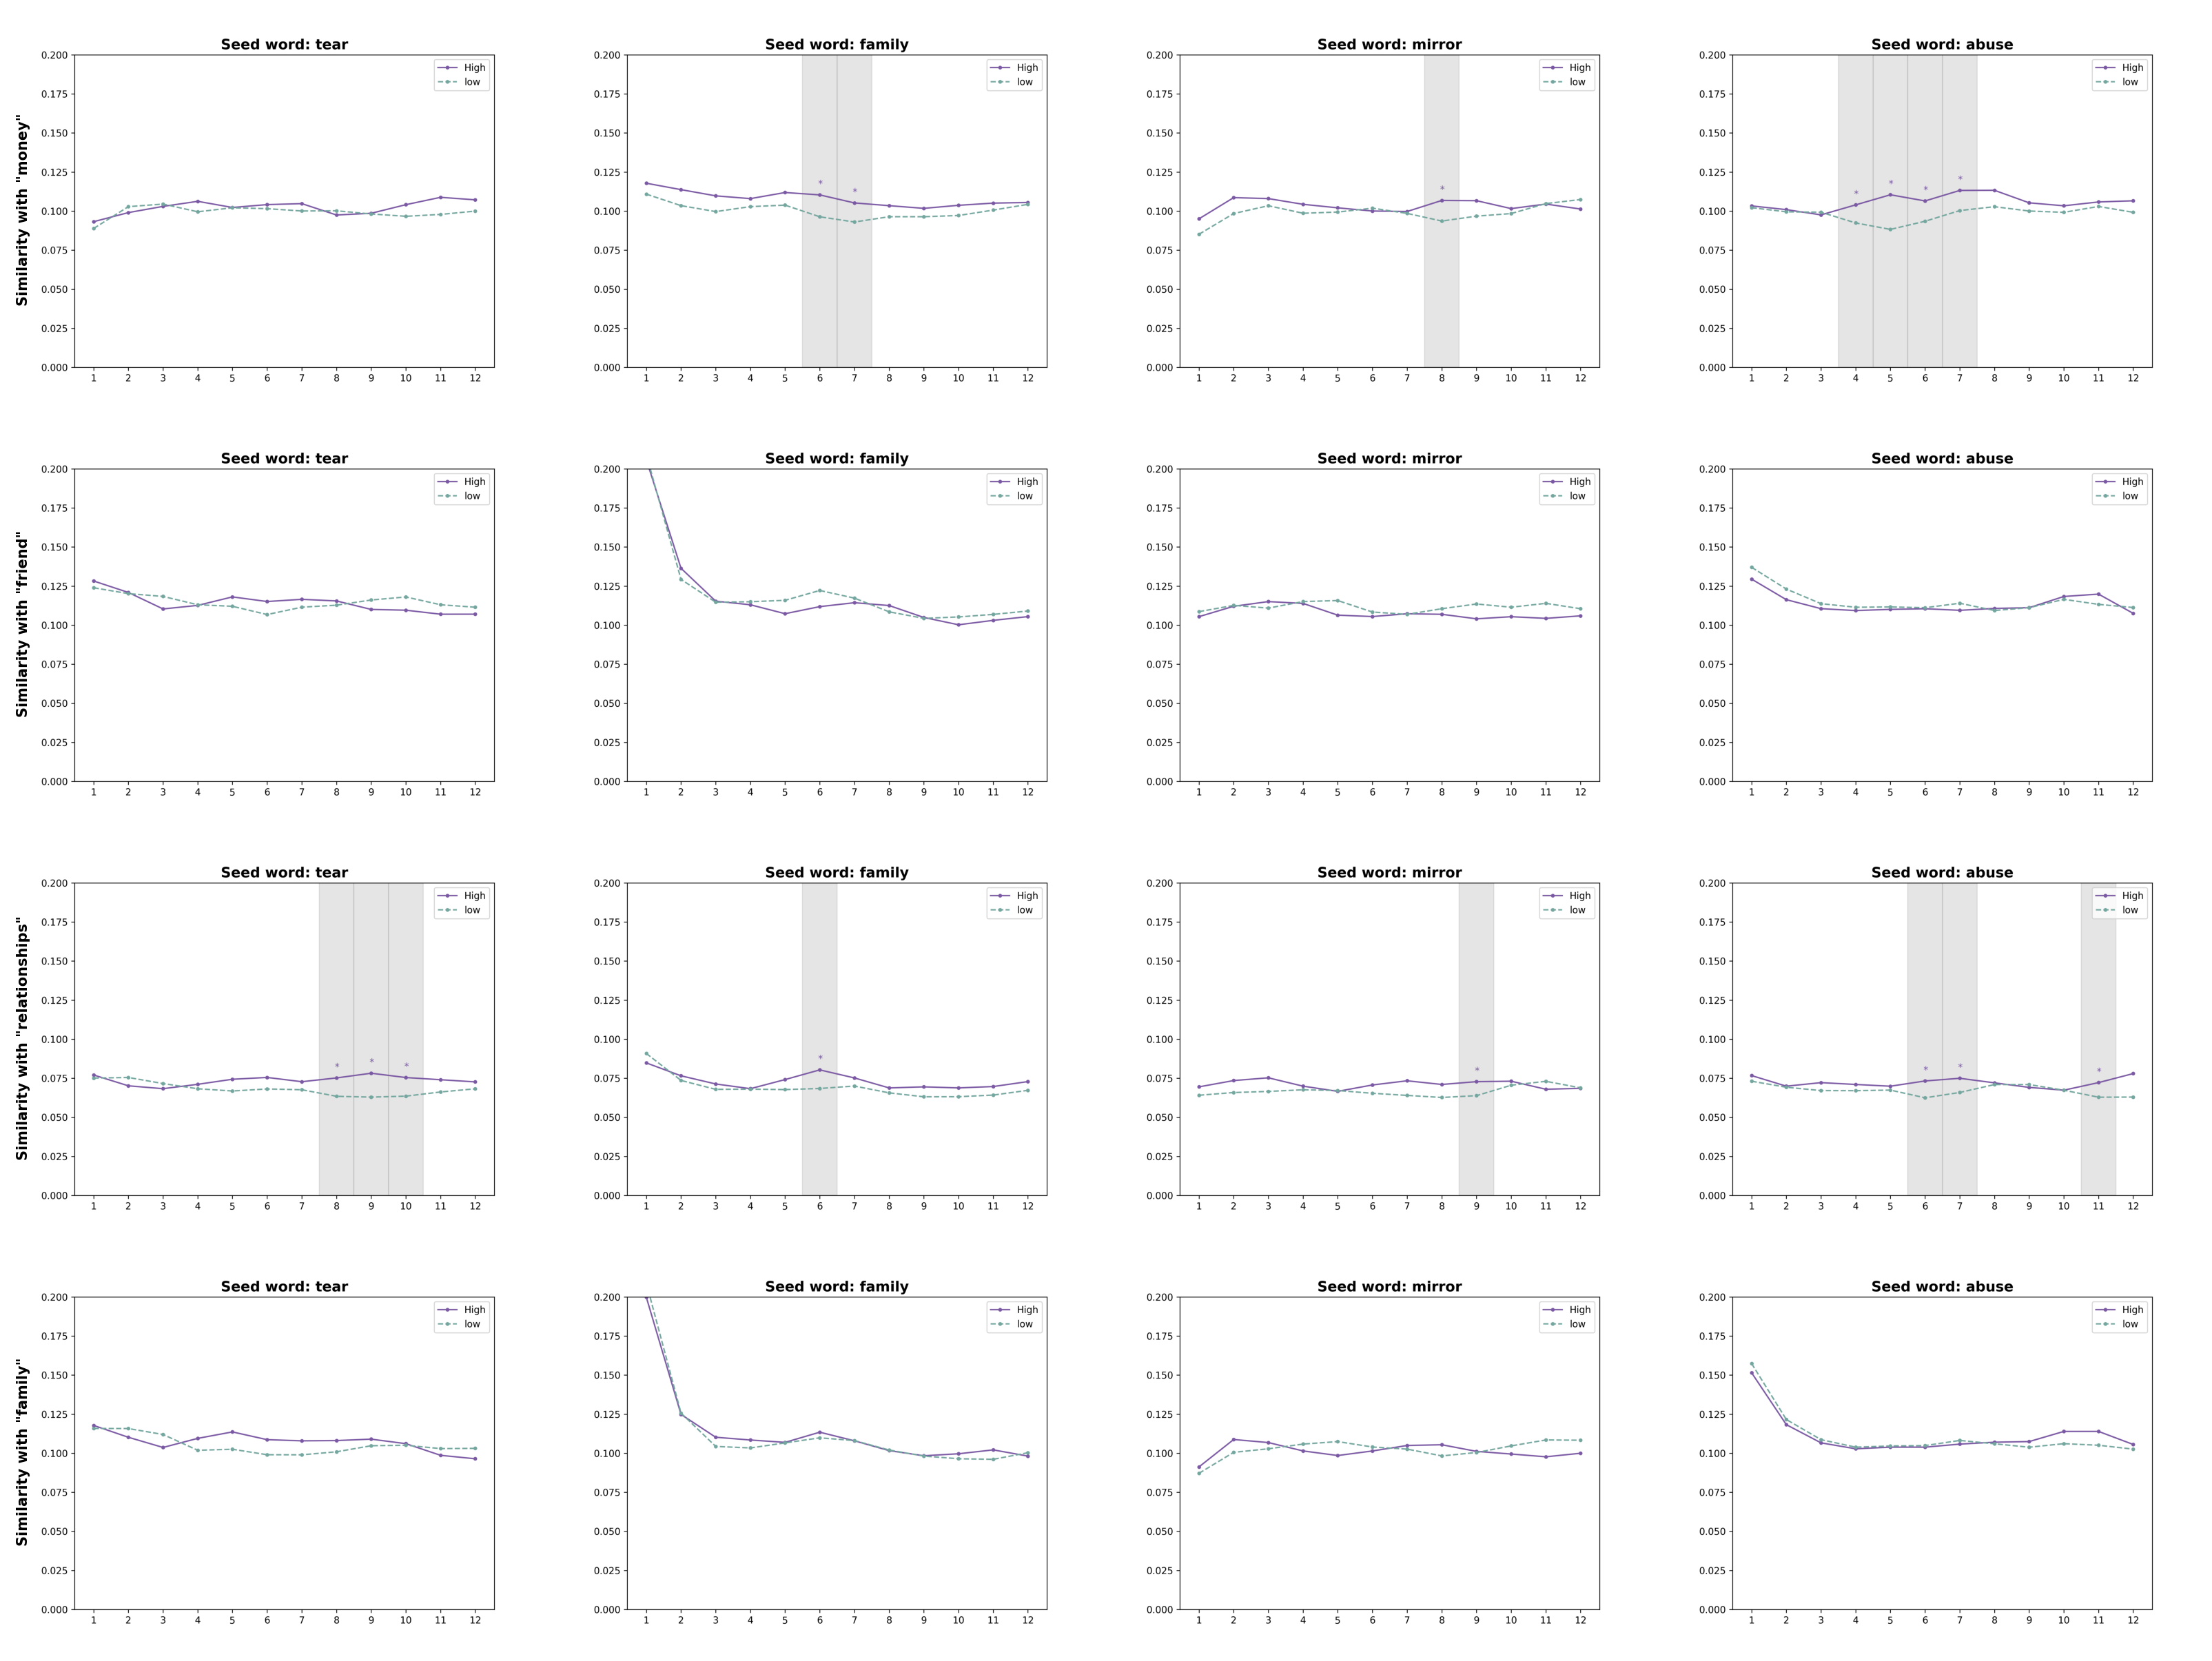

In [46]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(4, 4, figsize=(32, 24), constrained_layout=True)
plt.subplots_adjust(top=0, wspace=0, hspace=0)
ax = axes.flatten()

i = 0
for target in target_words:
    for seed in seed_words:
        # 이미지 불러오기
        img = mpimg.imread(graph_image_dir + f'line_graph_{seed}_{target}_ma{moving_size}_w{window_size}.png')
        
        ax[i].imshow(img)
        ax[i].axis('off')

        if i in [0, 4, 8, 12]:  # i가 0, 4, 8, 12일 때만 텍스트 추가
            ax[i].text(0.03, 0.5, f'Similarity with "{target}"', transform=ax[i].transAxes, rotation=90, fontsize=15, color='black',  weight='bold', ha='center', va='center')

        i += 1
# 전체 그리드 이미지를 저장
filepath = os.path.join(graph_image_dir, f'all_similarity_line_graph_ma{moving_size}_w{window_size}.png' )
plt.savefig(filepath, dpi=300)

# 화면에 그리드 이미지 표시
plt.show()

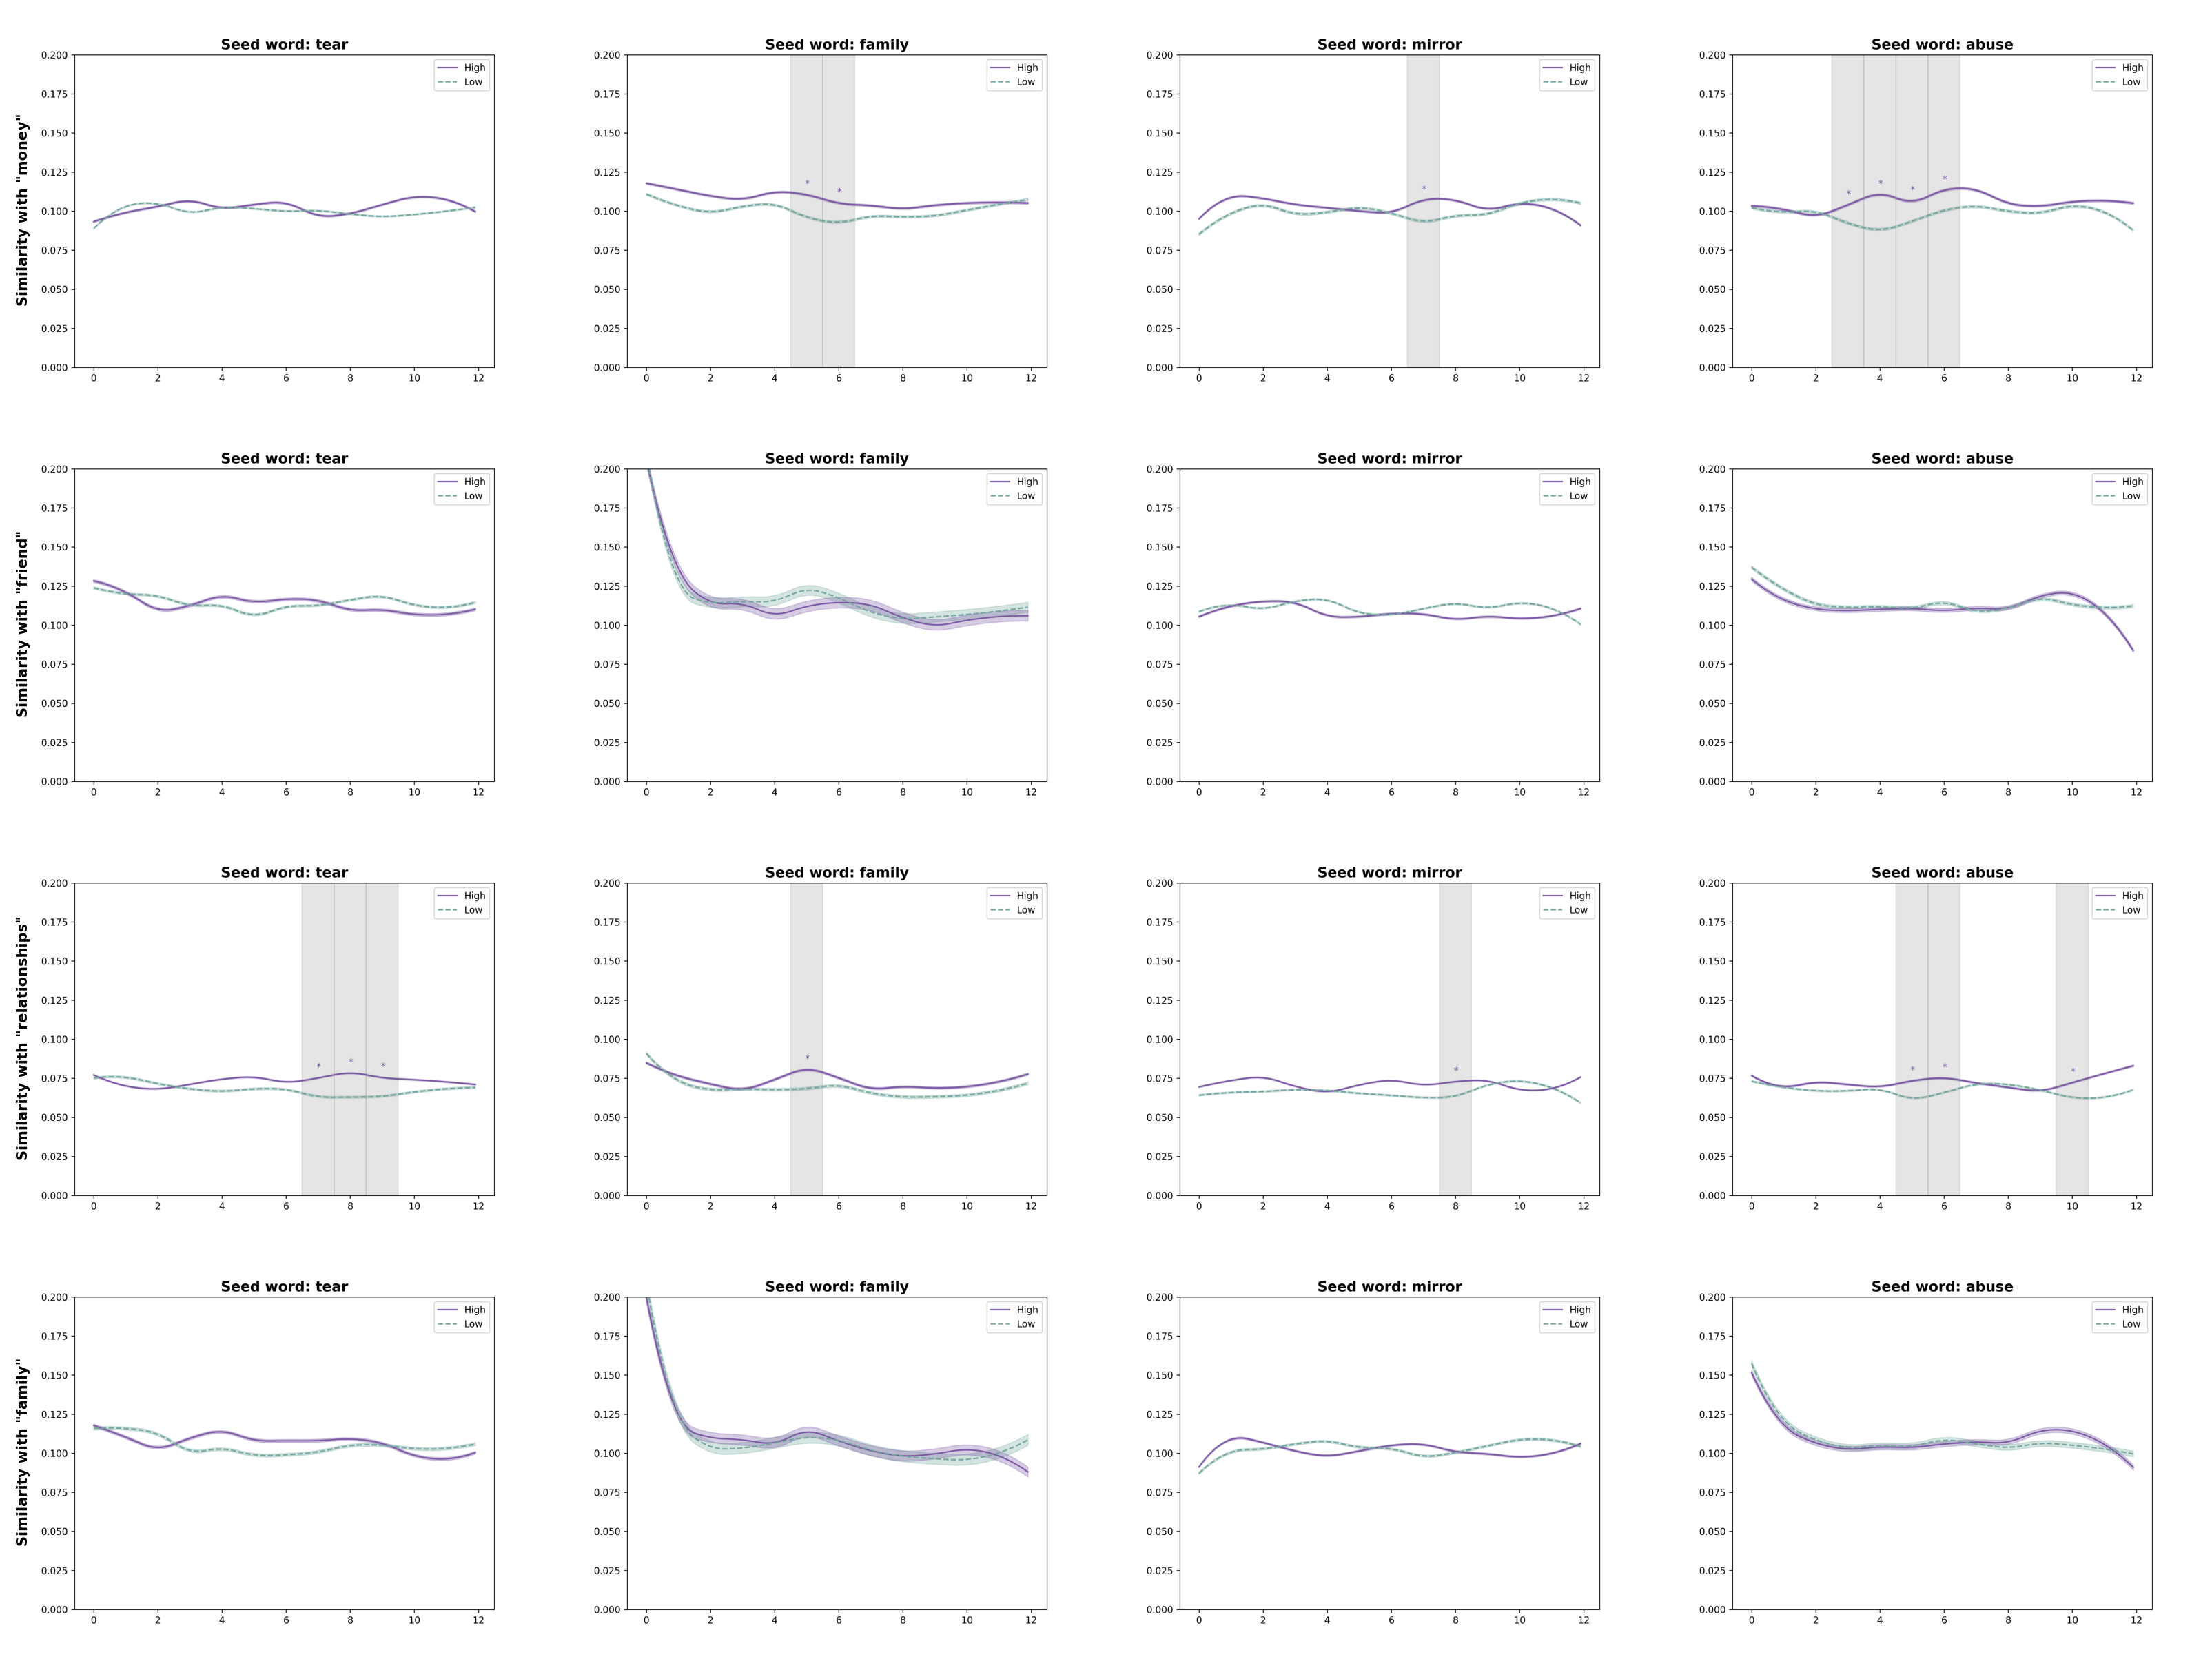

In [47]:
fig, axes = plt.subplots(4, 4, figsize=(32, 24), constrained_layout=True)
plt.subplots_adjust(top=0, wspace=0, hspace=0)

ax = axes.flatten()

i = 0
for target in target_words:
    for seed in seed_words:
        # 이미지 불러오기
        img = mpimg.imread(graph_image_dir + f'smoothing_graph_{seed}_{target}_ma{moving_size}_w{window_size}.png')
        
        ax[i].imshow(img)
        ax[i].axis('off')

        if i in [0, 4, 8, 12]:  # i가 0, 4, 8, 12일 때만 텍스트 추가
            ax[i].text(0.03, 0.5, f'Similarity with "{target}"', transform=ax[i].transAxes, rotation=90, fontsize=15, color='black',  weight='bold', ha='center', va='center')

        i += 1
# 전체 그리드 이미지를 저장
filepath = os.path.join(graph_image_dir, f'all_smoothing_line_graph_ma{moving_size}_w{window_size}.png')
plt.savefig(filepath, dpi=300)

# 화면에 그리드 이미지 표시
plt.show()
